In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/Users/user/Desktop/python projects/sales_records.csv')

In [30]:
#1 What are the top 5 regions in terms of total sales?

top_regions = df.groupby('Region')['Total Revenue'].sum().sort_values(ascending=False).head(5)
print(top_regions)

#Insights :
# Sub-Saharan Africa and Europe are leading by a significant margin in total revenue compared to other regions.
# These two regions alone contribute over half of the total sales across all regions, indicating a high demand or high-value products sold in these regions.
# This insight shows where the company generates the most revenue, which could guide decisions on region-specific marketing strategies or investment in distribution channels.



Region
Sub-Saharan Africa                   3.495845e+10
Europe                               3.424115e+10
Asia                                 1.929340e+10
Middle East and North Africa         1.692141e+10
Central America and the Caribbean    1.455373e+10
Name: Total Revenue, dtype: float64


In [32]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Create additional columns for analysis (e.g., month, year)
df['Order Month'] = df['Order Date'].dt.month
df['Order Year'] = df['Order Date'].dt.year

<Axes: title={'center': 'Monthly Sales Trend'}, xlabel='Month_Year'>

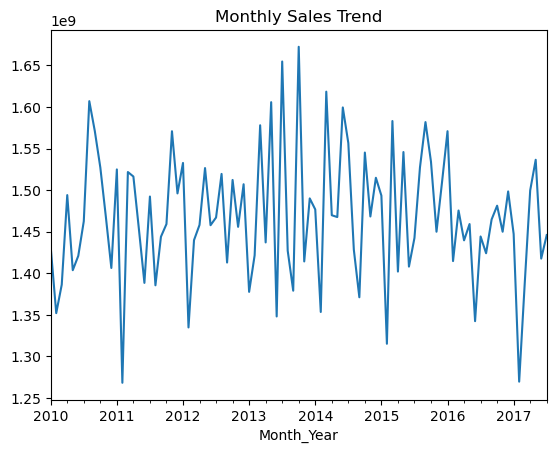

In [33]:
#2 What is the monthly sales trend over the years?


df['Month_Year'] = df['Order Date'].dt.to_period('M')

monthly_sales = df.groupby('Month_Year')['Total Revenue'].sum()
monthly_sales.plot(kind='line', title='Monthly Sales Trend')

#Insights :
# The sales trend shows fluctuations across different months, indicating possible seasonal demand or periodic spikes in sales activity.
# There are noticeable peaks during certain months, which could be attributed to promotional activities, holidays, or regional events.
# Identifying the months with the highest revenue can help the business plan for stock management, marketing campaigns, and resource allocation during peak periods.
# This analysis gives a clear picture of the overall sales performance and can guide planning and decision-making for optimizing sales strategies based on historical data.

In [35]:
#3 Which country had the highest number of sales orders?

top_countries_orders = df['Country'].value_counts().head(5)
print(top_countries_orders)

#Insights:
#Sudan leads in the number of sales orders, followed closely by New Zealand and Vatican City.
#The countries with the highest order counts vary greatly in size and region, suggesting a broad and diverse global distribution of sales.
#This insight indicates which countries have the most frequent customer interactions, which could help in improving delivery logistics, customer service, and local marketing strategies in these areas.

Country
Sudan           623
New Zealand     593
Vatican City    590
Malta           589
Mozambique      589
Name: count, dtype: int64


In [37]:
#4 What are the top 5 most sold product types?

top_sold_products = df.groupby('Item Type')['Units Sold'].sum().sort_values(ascending=False).head(5)
print(top_sold_products)

Item Type
Office Supplies    42293330
Cereal             42254418
Cosmetics          41924464
Baby Food          41911620
Clothes            41773440
Name: Units Sold, dtype: int64


Item Type                          Baby Food  Beverages    Cereal   Clothes  \
Region                                                                        
Asia                                0.375509   0.330032  0.430676  0.672035   
Australia and Oceania               0.375509   0.330032  0.430676  0.672035   
Central America and the Caribbean   0.375509   0.330032  0.430676  0.672035   
Europe                              0.375509   0.330032  0.430676  0.672035   
Middle East and North Africa        0.375509   0.330032  0.430676  0.672035   
North America                       0.375509   0.330032  0.430676  0.672035   
Sub-Saharan Africa                  0.375509   0.330032  0.430676  0.672035   

Item Type                          Cosmetics    Fruits  Household     Meat  \
Region                                                                       
Asia                                 0.39769  0.258307   0.247999  0.13558   
Australia and Oceania                0.39769  0.258307

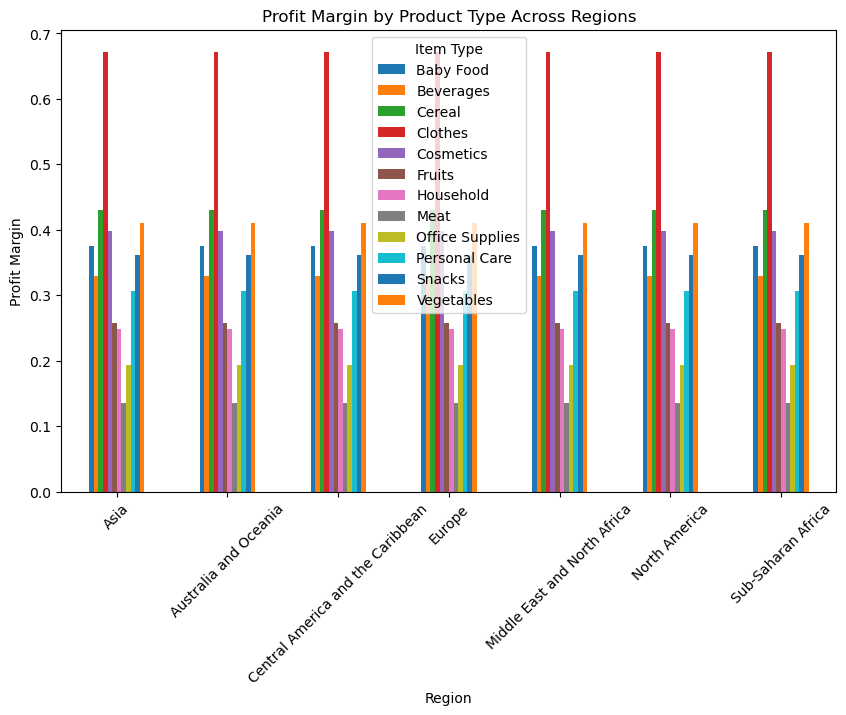

In [39]:
#5 What is the profit margin for each product category, and how does it vary across regions?

df['Profit Margin'] = df['Total Profit'] / df['Total Revenue']  # Calculate profit margin
profit_margin_region = df.groupby(['Region', 'Item Type'])['Profit Margin'].mean().unstack()
print(profit_margin_region)

# Visualize the profit margin across regions and products
profit_margin_region.plot(kind='bar', figsize=(10, 6))
plt.title('Profit Margin by Product Type Across Regions')
plt.ylabel('Profit Margin')
plt.xticks(rotation=45)
plt.show()

#Insights:

# Profitability Differences Across Regions: You can see which regions are the most profitable overall for example Clothes and cereals are always in high demand and which product types contribute most to profits in those regions.
# Product Type Profitability: The graph may show that certain product categories have higher profit margins than others especially Clothes , and this can vary by region.
# Strategic Recommendations: Based on the variation of profit margins, you could suggest focusing on specific regions or products that yield the highest returns. 

# Here, the regions which yield us the highest returns are Clothes , Vegetables and Cosmetics than any others
 

Region                Asia  Australia and Oceania  \
Sales Channel                                       
Offline        4983.774591            4990.000750   
Online         5027.885660            5066.262761   

Region         Central America and the Caribbean       Europe  \
Sales Channel                                                   
Offline                              5007.624863  5007.998681   
Online                               5033.280745  4936.605790   

Region         Middle East and North Africa  North America  Sub-Saharan Africa  
Sales Channel                                                                   
Offline                         5003.483341    5142.160665         4998.259302  
Online                          5052.755723    5025.661905         4986.087256  


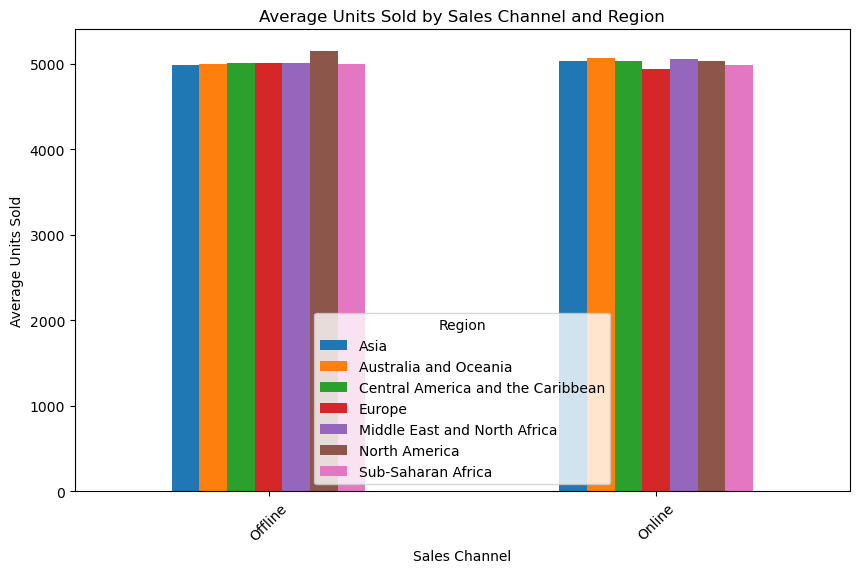

In [42]:
#6 How do different sales channels (online vs offline) affect average order quantity across regions?

avg_units_sold = df.groupby(['Sales Channel', 'Region'])['Units Sold'].mean().unstack()
print(avg_units_sold)

# Visualize
avg_units_sold.plot(kind='bar', figsize=(10, 6))
plt.title('Average Units Sold by Sales Channel and Region')
plt.ylabel('Average Units Sold')
plt.xticks(rotation=45)
plt.show()

#Insights

# In most of the regions , Online sales channels help in growth of sales.
# Some regions may have higher average order quantities overall, which can suggest a stronger demand for products in those areas.
# Surprisingly , North America exceeded more in sales than any other region even though its an Offline sales channel.
# To see it as an overall , Online sales channel has the highest reach.

Item Type
Clothes            204.910714
Cereal              75.646828
Vegetables          69.427032
Cosmetics           66.027418
Baby Food           60.130473
Snacks              56.588670
Beverages           49.260774
Personal Care       44.220928
Fruits              34.826590
Household           32.978469
Office Supplies     24.049451
Meat                15.684554
Name: ROI, dtype: float64


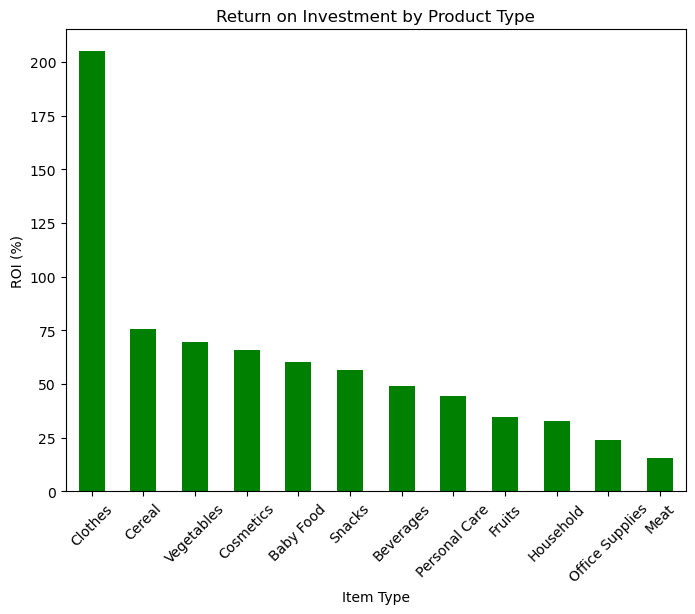

In [43]:
#7 Which products have the highest return on investment (ROI)?

df['ROI'] = (df['Total Profit'] / df['Total Cost']) * 100
product_roi = df.groupby('Item Type')['ROI'].mean().sort_values(ascending=False)
print(product_roi)

# Visualize
product_roi.plot(kind='bar', figsize=(8, 6), color='green')
plt.title('Return on Investment by Product Type')
plt.ylabel('ROI (%)')
plt.xticks(rotation=45)
plt.show()

#Insights:

# Clothes stand out as the most profitable product category by a large margin, offering the best return on investment. This may indicate a high demand, premium pricing, or low production costs relative to the profit made.
# Meat, office supplies, and household items have the lowest ROI, which may point to either high costs or lower margins. These product categories might not be the best investment for maximizing profit.
# Focus on high-ROI product categories like Clothes, Cereal, and Vegetables to maximize profitability.
# Review and analyze the cost structure or pricing strategies for low-ROI products such as Meat and Office Supplies to explore opportunities for improving their profitability.


Country
Jamaica                 0.362876
Cote d'Ivoire           0.358738
Ghana                   0.356497
Thailand                0.356296
United Arab Emirates    0.356202
Guatemala               0.355929
Macedonia               0.354708
Syria                   0.354578
Andorra                 0.354511
Australia               0.354470
Name: Profit Margin, dtype: float64


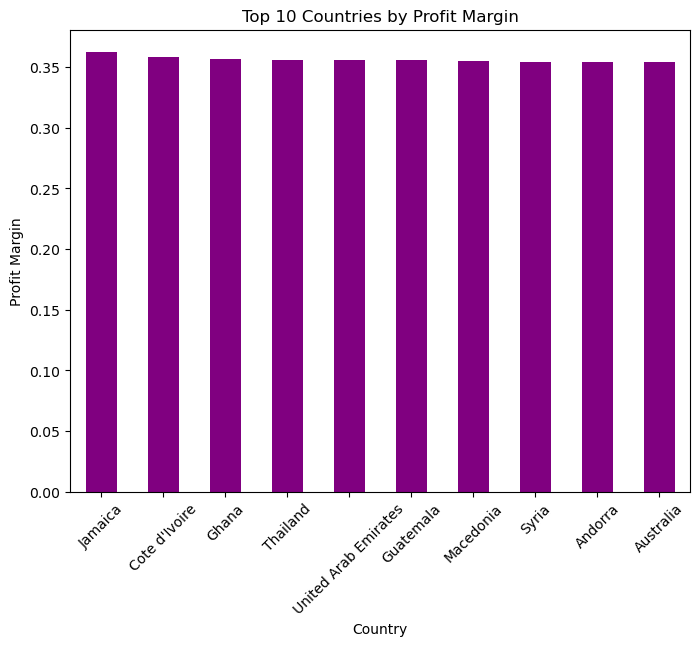

In [28]:
#8 What are the top 10 most profitable countries in terms of profit margins?

country_profit_margin = df.groupby('Country')['Profit Margin'].mean().sort_values(ascending=False).head(10)
print(country_profit_margin)

# Visualization
country_profit_margin.plot(kind='bar', figsize=(8, 6), color='purple')
plt.title('Top 10 Countries by Profit Margin')
plt.ylabel('Profit Margin')
plt.xticks(rotation=45)
plt.show()

#Insights:

# Jamaica, Cote d'Ivoire, and Ghana are the top three countries, showing the most significant potential for profitability. This may be due to favorable market conditions, strong product demand, or efficient cost management in these regions.
# Countries like Thailand, UAE, and Australia, despite being in different parts of the world, also present strong profit margins. This suggests that the company's products or services have broad global appeal and are well-positioned across diverse markets.
# Focus on high-margin countries like Jamaica, Cote d'Ivoire, and Ghana for expanding operations, as these markets are yielding the highest profit margins.
# Optimize performance in lower-margin countries by analyzing potential inefficiencies or market conditions that can be improved to raise profitability.

Order Priority
M    8520
L    8497
C    8475
H    8458
Name: count, dtype: int64


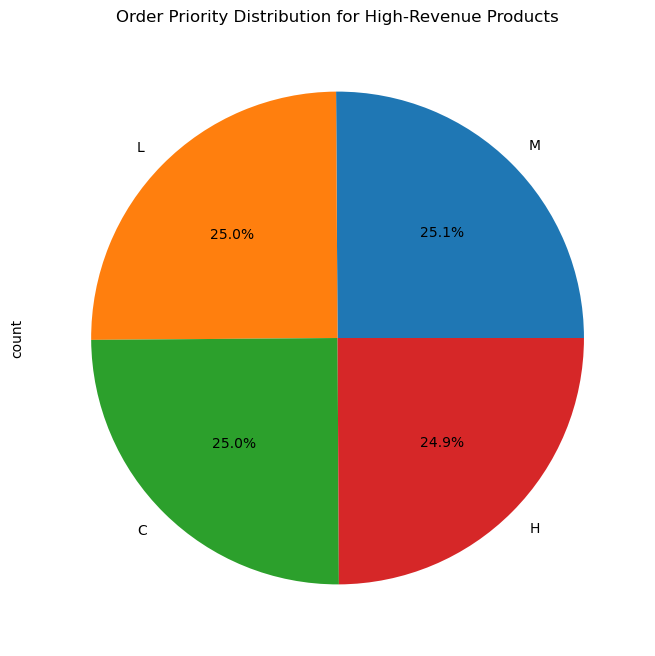

In [15]:
#9 What are the most frequent order priorities for high-revenue products?

high_revenue_products = df[df['Total Revenue'] > df['Total Revenue'].mean()]
priority_count = high_revenue_products['Order Priority'].value_counts()
print(priority_count)

# Visualization
priority_count.plot(kind='pie', autopct='%1.1f%%', figsize=(8, 8), title='Order Priority Distribution for High-Revenue Products')
plt.show()

#Insights:

#  Medium Priority (M) is the most frequent priority level for high-revenue products, with 8520 orders, though only slightly more common than other priorities. This suggests that even medium-priority orders can drive substantial revenue.
# Low priority (L) with 8497 orders, low-priority orders are nearly as frequent as medium-priority ones, indicating that products marked as low priority are still generating significant revenue.
# Critical Priority (C) accounts for 8475 orders, and high priority for 8458 orders. This suggests that while high-revenue products do not overwhelmingly depend on critical or high-priority orders, these categories still represent a considerable portion of revenue-driving orders.
# Analyze Specific Categories: It might be beneficial to analyze which specific products fall under each priority level and see if any patterns emerge, allowing for more optimized prioritization strategies in the future.
# Maintain Flexibility in Prioritization: Since all priority levels contribute almost equally, there's no need to focus exclusively on high or critical priorities for revenue growth. You can afford flexibility in prioritizing orders without sacrificing revenue

In [46]:
#10 Which products have the highest variance in unit price, and does this impact total revenue?

product_price_variance = df.groupby('Item Type')['Unit Price'].var().reset_index().sort_values(by='Unit Price', ascending=False)
print(product_price_variance)

# Checking the impact on total revenue
high_variance_products = product_price_variance[product_price_variance['Unit Price'] > product_price_variance['Unit Price'].mean()]
high_variance_revenue = df[df['Item Type'].isin(high_variance_products['Item Type'])].groupby('Item Type')['Total Revenue'].sum().reset_index()
print(high_variance_revenue)

#Insights:

# Constant Pricing: The fixed unit prices across all products suggest a stable pricing strategy. Since prices are constant, factors like discounts, regional price differences, or dynamic pricing models are not affecting the unit prices of products in this dataset.
# Revenue Analysis: Because the unit price does not vary, revenue is driven purely by the volume of units sold rather than by fluctuations in price. This could imply that the company's revenue strategy is based on selling more units rather than adjusting prices.
# Evaluate Pricing Strategy: If this constant pricing strategy is intentional, it may indicate a focus on selling high volumes. However, the company might explore dynamic pricing strategies or regional pricing adjustments to potentially increase revenue.
# Focus on Sales Volume: Since revenue is currently driven by units sold, the company could focus on boosting sales volumes through marketing or distribution strategies for specific products.

          Item Type  Unit Price
0         Baby Food         0.0
1         Beverages         0.0
2            Cereal         0.0
3           Clothes         0.0
4         Cosmetics         0.0
5            Fruits         0.0
6         Household         0.0
7              Meat         0.0
8   Office Supplies         0.0
9     Personal Care         0.0
10           Snacks         0.0
11       Vegetables         0.0
Empty DataFrame
Columns: [Item Type, Total Revenue]
Index: []


In [48]:
#11 Which combination of sales channel and order priority leads to the highest total profit?

channel_priority_profit = df.groupby(['Sales Channel', 'Order Priority'])['Total Profit'].sum().reset_index()
channel_priority_profit_sorted = channel_priority_profit.sort_values(by='Total Profit', ascending=False)
print(channel_priority_profit_sorted.head(10))

#Insights:

#  Medium-priority offline orders outperform all other combinations, suggesting that even orders with moderate urgency can drive significant profits when processed through offline channels.
# Online orders, regardless of priority (critical, low, or medium), consistently rank among the top contributors to profit. This highlights the importance of the online channel in driving profitability.
# Even low-priority orders, particularly in the online channel, generate substantial profits, which could imply high-volume, low-urgency orders that still lead to strong financial returns.
# Since this combination yields the highest total profit, enhancing the offline experience for medium-priority customers could further maximize profitability.
#Given the consistently high profitability of online orders across priorities, further investment in the online sales infrastructure could help capture even more profit.
# Leverage marketing strategies or promotions to increase the volume of low-priority orders, especially through online channels, as they still contribute significantly to total profit.

  Sales Channel Order Priority  Total Profit
3       Offline              M  4.970097e+09
4        Online              C  4.951311e+09
6        Online              L  4.938647e+09
1       Offline              H  4.932194e+09
5        Online              H  4.914985e+09
7        Online              M  4.912181e+09
2       Offline              L  4.906661e+09
0       Offline              C  4.883048e+09


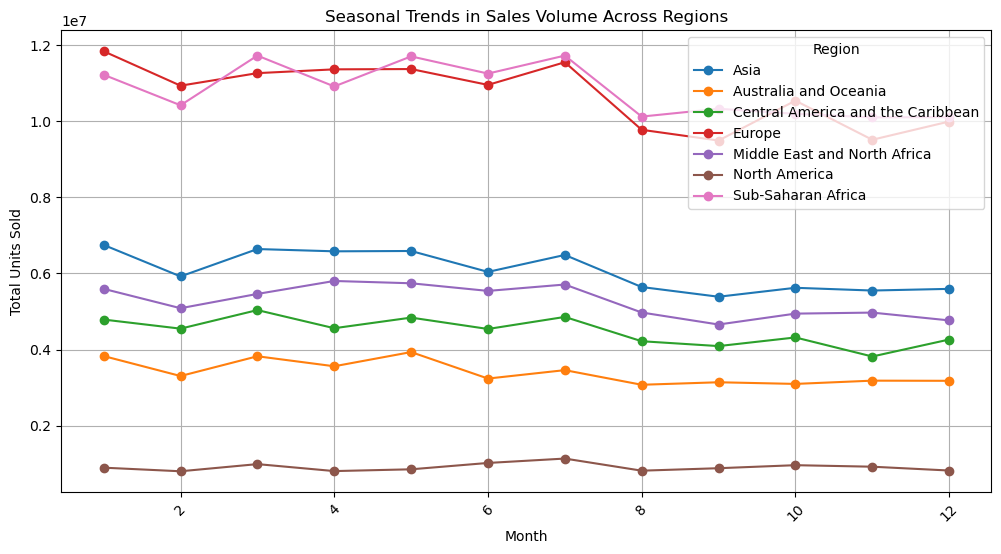

In [58]:
#12 What are the seasonal trends in sales volume (units sold) across different regions?

# Ensure 'Order Date' is in datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Extract month for grouping
df['Month'] = df['Order Date'].dt.month

# Total Units Sold by Month and Region
seasonal_trends = df.groupby(['Month', 'Region'])['Units Sold'].sum().unstack()

# Visualization
seasonal_trends.plot(kind='line', figsize=(12, 6), marker='o')
plt.title('Seasonal Trends in Sales Volume Across Regions')
plt.xlabel('Month')
plt.ylabel('Total Units Sold')
plt.xticks(rotation=45)
plt.legend(title='Region')
plt.grid()
plt.show()

#Insights:

# The analysis of seasonal trends in sales volume across regions provides valuable insights into consumer behavior, enabling data-driven decision-making that enhances operational efficiency and profitability. By leveraging this information, businesses can optimize their strategies to align with seasonal demand patterns, ultimately leading to improved customer satisfaction and increased revenue.


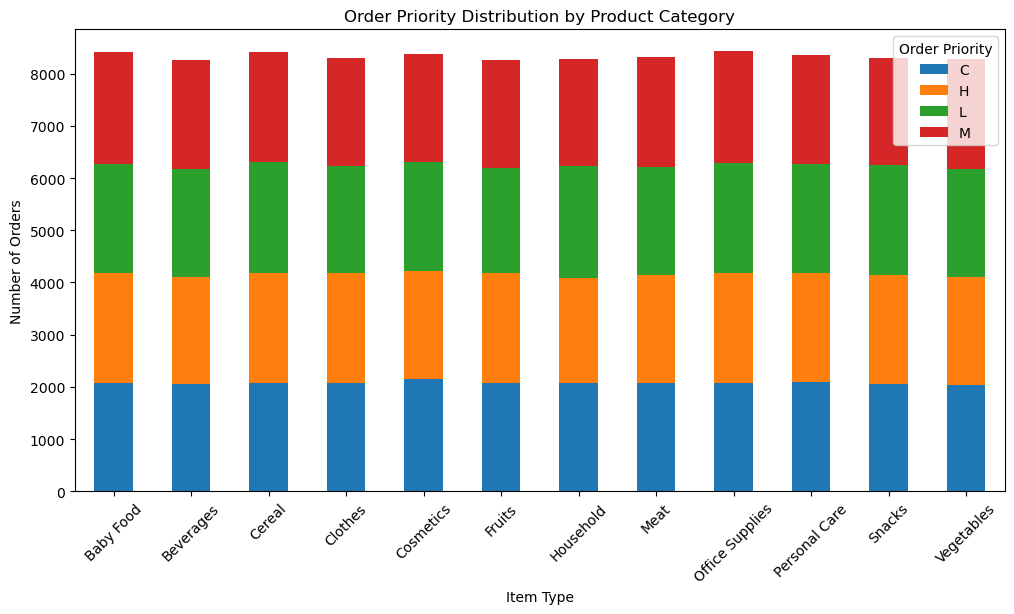

In [60]:
#13 How does the distribution of order priorities differ between product categories?

# Order Priority Distribution by Item Type
priority_distribution = df.groupby(['Item Type', 'Order Priority']).size().unstack().fillna(0)

# Visualization
priority_distribution.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Order Priority Distribution by Product Category')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.legend(title='Order Priority')
plt.show()

#Insights:

# Order Priority Composition: The stacked bar chart visually represents how different order priorities (High, Medium, Low, Critical) are distributed across various product categories
# Demand for Urgent Fulfillment: Categories with a high number of critical and high-priority orders may indicate strong customer demand for those products, suggesting that customers view them as essential or time-sensitive.
# Category-Specific Trends: By analyzing the priorities for each item type, businesses can tailor their logistics and order processing strategies.
# Sales Strategy Development: Understanding the priority distribution allows for strategic decision-making regarding marketing and sales efforts

In [18]:
# Univariate analysis for numerical columns
numerical_cols = ['Units Sold', 'Unit Price', 'Total Revenue', 'Total Cost', 'Total Profit']

for col in numerical_cols:
    print(f"Univariate Analysis for {col}:")
    print(df[col].describe())  # Provides count, mean, std, min, 25%, 50%, 75%, max
    print("\n")

# Univariate analysis for categorical columns
categorical_cols = ['Region', 'Item Type', 'Sales Channel', 'Order Priority']

for col in categorical_cols:
    print(f"Univariate Analysis for {col}:")
    print(df[col].value_counts())  # Shows the frequency of each category
    print("\n")

Univariate Analysis for Units Sold:
count    100000.000000
mean       5001.446170
std        2884.575424
min           1.000000
25%        2505.000000
50%        5007.000000
75%        7495.250000
max       10000.000000
Name: Units Sold, dtype: float64


Univariate Analysis for Unit Price:
count    100000.000000
mean        266.703989
std         216.940081
min           9.330000
25%         109.280000
50%         205.700000
75%         437.200000
max         668.270000
Name: Unit Price, dtype: float64


Univariate Analysis for Total Revenue:
count    1.000000e+05
mean     1.336067e+06
std      1.471768e+06
min      1.866000e+01
25%      2.797533e+05
50%      7.898916e+05
75%      1.836490e+06
max      6.682700e+06
Name: Total Revenue, dtype: float64


Univariate Analysis for Total Cost:
count    1.000000e+05
mean     9.419755e+05
std      1.151828e+06
min      1.384000e+01
25%      1.629283e+05
50%      4.679374e+05
75%      1.209475e+06
max      5.249075e+06
Name: Total Cost, dtype: 

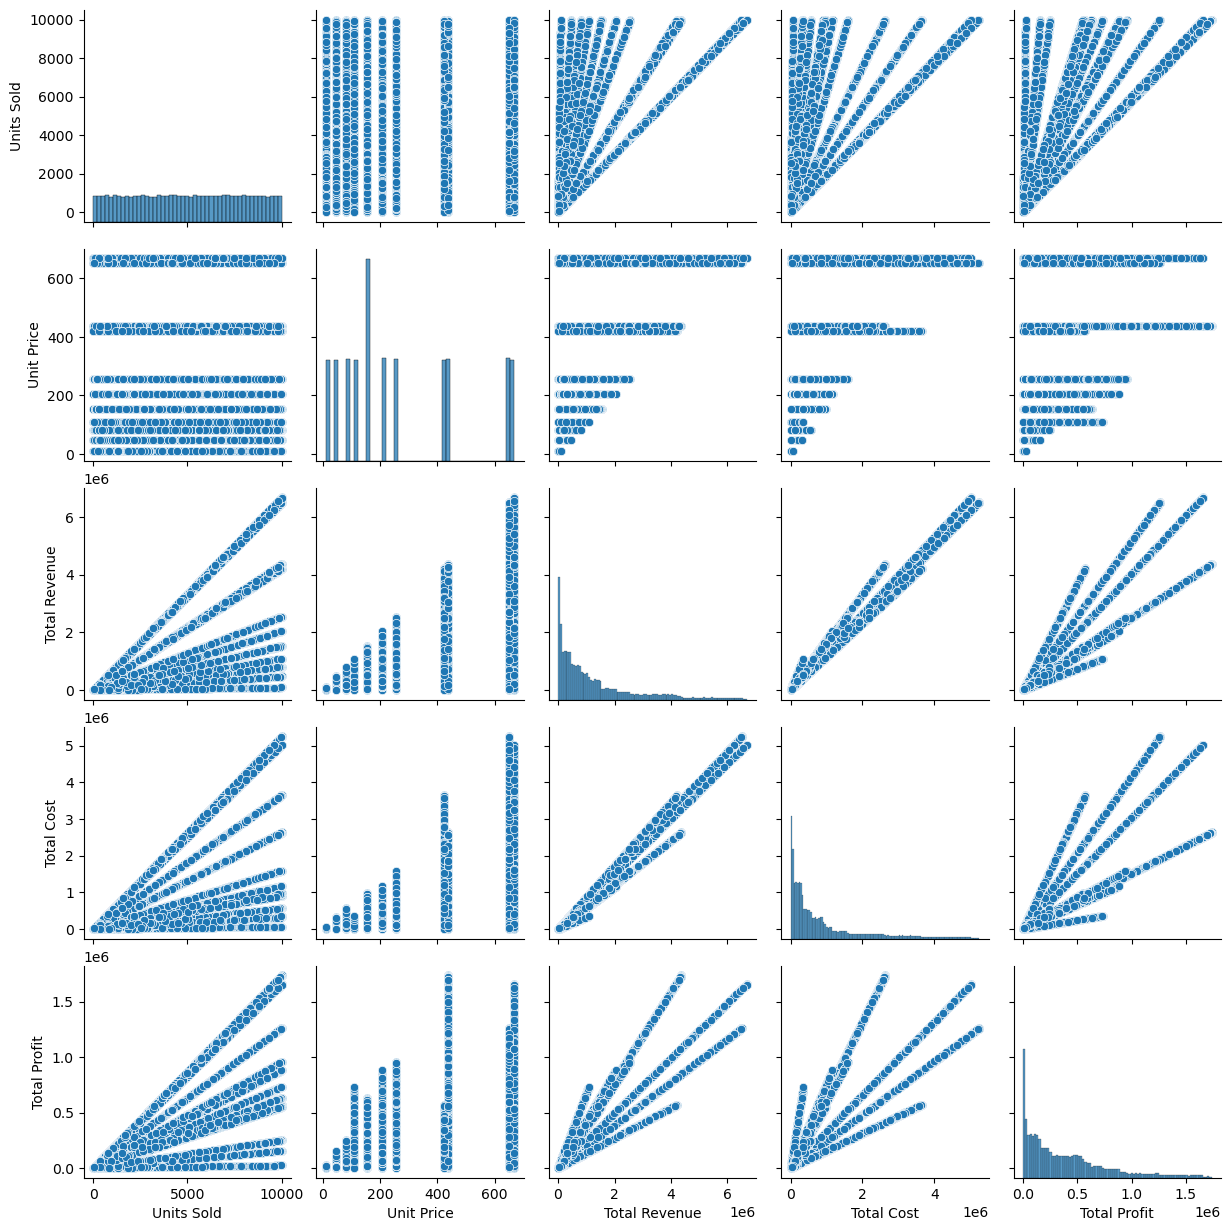

Item Type
Baby Food          477893.171548
Beverages           78725.184740
Cereal             444521.896523
Clothes            369441.405780
Cosmetics          870896.840583
Fruits              11900.439985
Household          830027.312799
Meat               286999.398125
Office Supplies    633697.236233
Personal Care      124394.454323
Snacks             276755.889851
Vegetables         314467.253886
Name: Total Profit, dtype: float64
Region
Asia                                 1.929340e+10
Australia and Oceania                1.070152e+10
Central America and the Caribbean    1.455373e+10
Europe                               3.424115e+10
Middle East and North Africa         1.692141e+10
North America                        2.937002e+09
Sub-Saharan Africa                   3.495845e+10
Name: Total Revenue, dtype: float64


In [19]:
# Bivariate analysis between numerical variables
sns.pairplot(df[['Units Sold', 'Unit Price', 'Total Revenue', 'Total Cost', 'Total Profit']])
plt.show()

# Bivariate analysis between a categorical and a numerical variable
print(df.groupby('Item Type')['Total Profit'].mean())  # Average profit by product type

print(df.groupby('Region')['Total Revenue'].sum()) 

In [20]:
# Outliers 
numerical_cols = ['Units Sold', 'Unit Price', 'Total Revenue', 'Total Cost', 'Total Profit']
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Outliers in {col}: {outliers.shape[0]} outliers detected.")

Outliers in Units Sold: 0 outliers detected.
Outliers in Unit Price: 0 outliers detected.
Outliers in Total Revenue: 6597 outliers detected.
Outliers in Total Cost: 9678 outliers detected.
Outliers in Total Profit: 4125 outliers detected.


C:\Users\user\AppData\Local\Temp\ipykernel_13856\1836040382.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['Month'] = filtered_data['Order Date'].dt.month


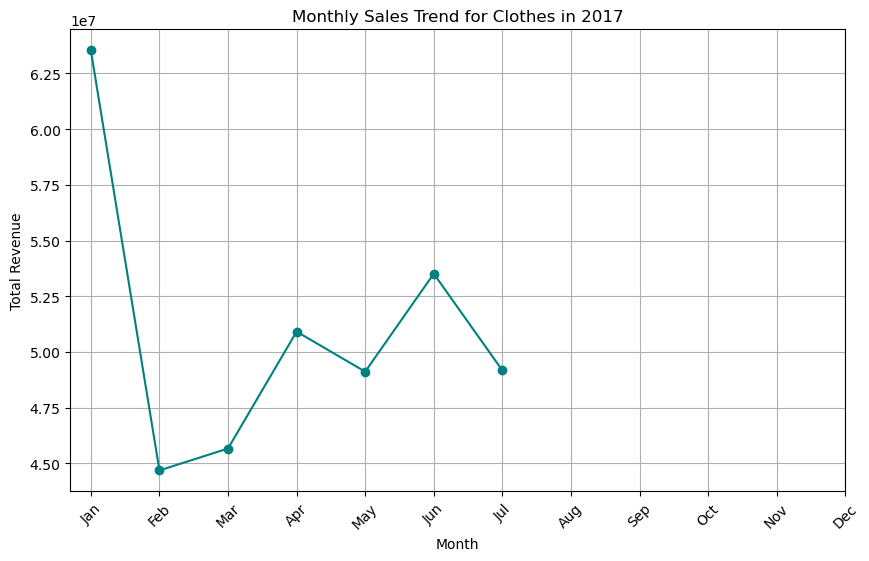

In [88]:
# Ensure 'Order Date' is in datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Filter for a specific year and product type
specific_year = 2017
specific_product = 'Clothes'
filtered_data = df[(df['Order Date'].dt.year == specific_year) & (df['Item Type'] == specific_product)]

# Extract month for grouping
filtered_data['Month'] = filtered_data['Order Date'].dt.month

# Calculate total revenue by month
monthly_sales = filtered_data.groupby('Month')['Total Revenue'].sum()

# Visualization
plt.figure(figsize=(10, 6))
monthly_sales.plot(kind='line', marker='o', color='teal')
plt.title(f'Monthly Sales Trend for {specific_product} in {specific_year}')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
plt.grid()
plt.show()

#Insights:

# The plot reveals how revenue fluctuates across different months. Peaks in revenue during certain months may indicate seasonal demand for the product
# As we can see, there is a major downfall of revenue from the start of the 2017 as January had the peak revenue and suddenly next month the major downfall occured 
# After february , the revenue cant able to reach the peak but managed a bit to increase in some decent rates and ended with 4.75 in July.
# Identifying months with lower revenue helps businesses understand when sales tend to drop. These periods may correspond to lower seasonal demand or reduced consumer spending. Recognizing these trends allows businesses to plan targeted promotions or adjust inventory levels to avoid overstocking.
# If the monthly sales trend is relatively stable, it suggests consistent demand for the product throughout the year. This consistency allows for smoother inventory management and sales forecasting. On the other hand, highly variable sales might call for more dynamic sales strategies to manage demand effectively.


C:\Users\user\AppData\Local\Temp\ipykernel_13856\449632683.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['Year'] = filtered_data['Order Date'].dt.year


   Year  Total_Revenue  Total_Units_Sold  Total_Profit
0  2010   6.030082e+08           5518011  4.052427e+08
1  2011   5.935292e+08           5431270  3.988725e+08
2  2012   5.640951e+08           5161924  3.790917e+08
3  2013   6.183818e+08           5658691  4.155743e+08
4  2014   5.944092e+08           5439323  3.994639e+08
5  2015   6.091995e+08           5574666  4.094035e+08
6  2016   6.257865e+08           5726450  4.205505e+08
7  2017   3.565921e+08           3263105  2.396424e+08


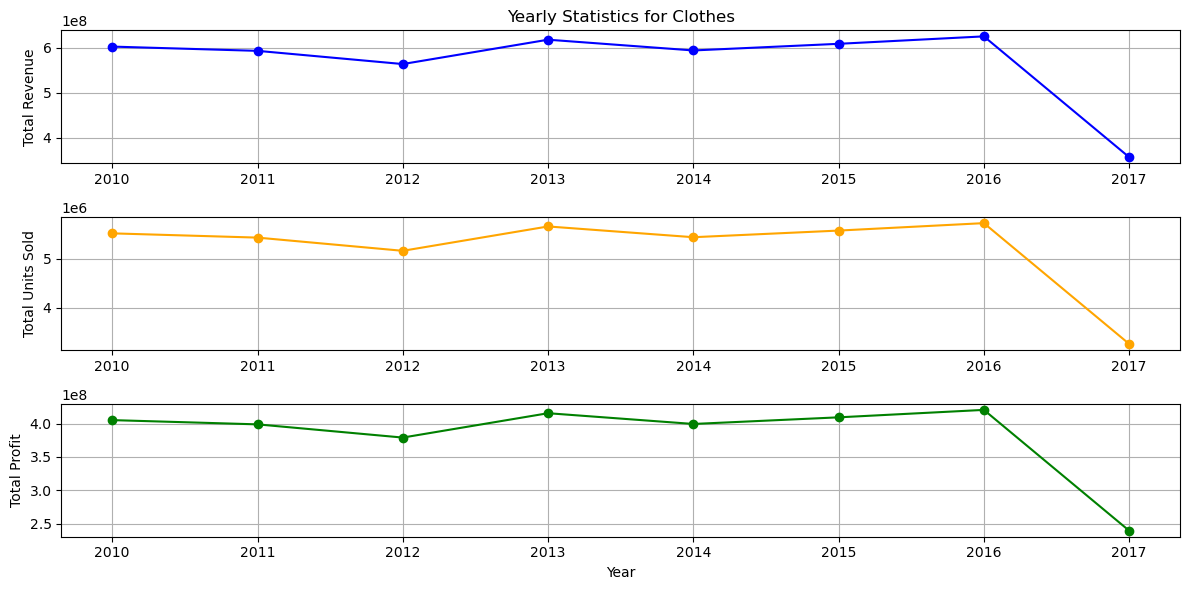

In [84]:
# Ensure 'Order Date' is in datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Filter for a specific product type
specific_product = 'Clothes'  # Change this to the product you're interested in
filtered_data = df[df['Item Type'] == specific_product]

# Extract year for grouping
filtered_data['Year'] = filtered_data['Order Date'].dt.year

# Calculate yearly statistics
yearly_stats = filtered_data.groupby('Year').agg(
    Total_Revenue=('Total Revenue', 'sum'),
    Total_Units_Sold=('Units Sold', 'sum'),
    Total_Profit=('Total Profit', 'sum')
).reset_index()

# Display the yearly statistics
print(yearly_stats)

# Visualization
plt.figure(figsize=(12, 6))

# Plotting Total Revenue
plt.subplot(3, 1, 1)
plt.plot(yearly_stats['Year'], yearly_stats['Total_Revenue'], marker='o', color='blue')
plt.title(f'Yearly Statistics for {specific_product}')
plt.ylabel('Total Revenue')
plt.xticks(yearly_stats['Year'])
plt.grid()

# Plotting Total Units Sold
plt.subplot(3, 1, 2)
plt.plot(yearly_stats['Year'], yearly_stats['Total_Units_Sold'], marker='o', color='orange')
plt.ylabel('Total Units Sold')
plt.xticks(yearly_stats['Year'])
plt.grid()

# Plotting Total Profit
plt.subplot(3, 1, 3)
plt.plot(yearly_stats['Year'], yearly_stats['Total_Profit'], marker='o', color='green')
plt.ylabel('Total Profit')
plt.xticks(yearly_stats['Year'])
plt.xlabel('Year')
plt.grid()

plt.tight_layout()
plt.show()

#Insights:

# The total revenue plot reveals how sales have changed year by year. Peaks in revenue may indicate periods of higher consumer demand, successful promotional campaigns, or expansion into new markets.
# A comparison between the units sold and revenue trends can reveal pricing strategies or changes in consumer behavior. For example, if units sold remain steady or increase while revenue drops, it could indicate a decline in unit price or the introduction of discounts. If both metrics increase simultaneously, it suggests strong product demand.
# The total profit trend shows the business's ability to generate profit over the years. If profit increases while revenue grows, it indicates operational efficiency or better cost management. On the other hand, if profit remains stagnant or decreases despite rising revenue, there could be higher costs or inefficient scaling.

C:\Users\user\AppData\Local\Temp\ipykernel_13856\2576967754.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['Year'] = filtered_data['Order Date'].dt.year


Region
North America                        2.508670e+06
Australia and Oceania                7.007794e+06
Central America and the Caribbean    1.275678e+07
Asia                                 1.282218e+07
Middle East and North Africa         1.794869e+07
Sub-Saharan Africa                   2.357408e+07
Europe                               2.540398e+07
dtype: float64


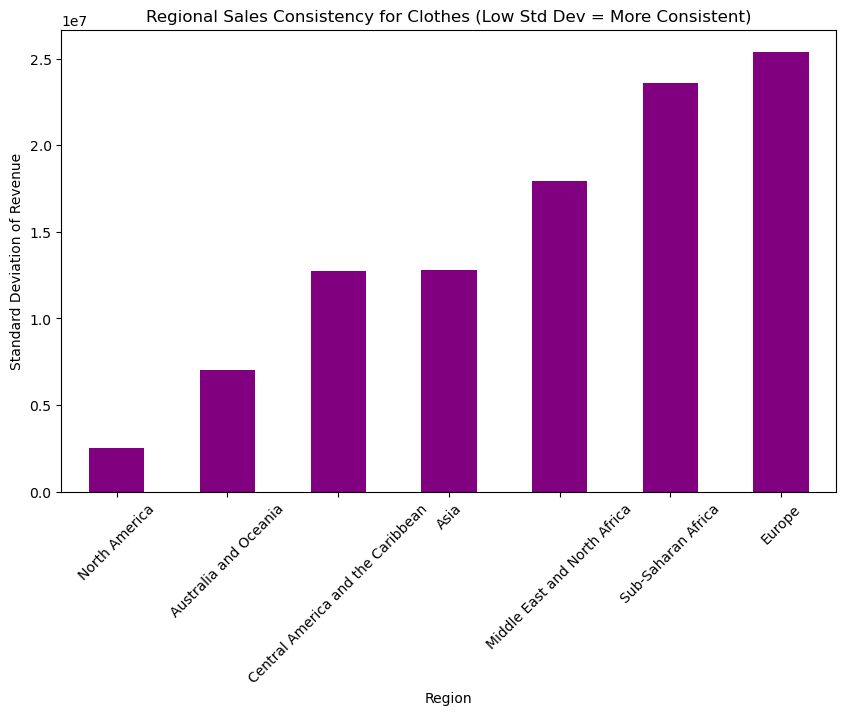

In [90]:
# Filter for a specific product type
specific_product = 'Clothes'  # Change to the product type you want
filtered_data = df[df['Item Type'] == specific_product]

# Extract year and group by year and region
filtered_data['Year'] = filtered_data['Order Date'].dt.year
region_sales = filtered_data.groupby(['Year', 'Region'])['Total Revenue'].sum().unstack().fillna(0)

# Calculate the standard deviation of sales across years for each region
region_consistency = region_sales.std().sort_values()

# Display the regions with the most consistent sales performance
print(region_consistency)

# Visualization
plt.figure(figsize=(10, 6))
region_consistency.plot(kind='bar', color='purple')
plt.title(f'Regional Sales Consistency for {specific_product} (Low Std Dev = More Consistent)')
plt.ylabel('Standard Deviation of Revenue')
plt.xticks(rotation=45)
plt.show()

#Insights: 

# North America shows the lowest standard deviation in sales, indicating that this region has had the most stable and predictable revenue for the product. This suggests a strong and steady demand for Clothes in North America, making it a reliable market for this product category.
# Australia and Oceania and Central America and the Caribbean also display relatively low variability in sales, showing moderate consistency. This suggests these regions have more predictable performance compared to others, though with some fluctuations in demand over the years.
# Europe, Sub-Saharan Africa, and Middle East and North Africa exhibit higher standard deviations in their sales, meaning sales in these regions fluctuate more significantly from year to year. This may be due to factors such as changing market conditions, economic shifts, or competitive pressures.
# Understanding which regions have more consistent sales can help inform strategic decisions. Regions with high consistency (like North America) might require less aggressive marketing and sales efforts to maintain revenue levels. In contrast, regions with high variability may need targeted strategies, such as promotions or market research, to stabilize and improve sales.